# T12D SVR With Core NIR Features And CNN Woodtype Probabilities

指定の 5 つの NIR 特徴量と CNN-2D woodtype probability 特徴量を組み合わせた SVR 予測実験。GroupKFold by 樹種で OOF 評価し、RMSE、樹種別 RMSE、実測/予測乾燥カーブを保存します。

In [1]:
from __future__ import annotations

from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def find_project_root() -> Path:
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Project root not found. Run this notebook inside the repository.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config.settings import DataConfig
from src.data.preprocessing import savitzky_golay_derivative
from src.utils.plotting import configure_matplotlib_japanese

sns.set_theme(style="whitegrid")
configure_matplotlib_japanese()

config = DataConfig()
ID_COL = "sample number"
GROUP_COL = "species number"
SPECIES_COL = "樹種"
TARGET_COL = "含水率"

RESULT_DIR = PROJECT_ROOT / "outputs" / "svr_core_features_cnn_woodtype"
FIGURE_DIR = RESULT_DIR / "figures"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("RESULT_DIR =", RESULT_DIR)

PROJECT_ROOT = C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D
RESULT_DIR = C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\svr_core_features_cnn_woodtype


## Utilities

In [2]:
SOFTWOOD_CANDIDATES = ["softwood_prob", "prob_softwood", "p_softwood", "woodtype_softwood_prob", "prob_woodtype_softwood"]
HARDWOOD_CANDIDATES = ["hardwood_prob", "prob_hardwood", "p_hardwood", "woodtype_hardwood_prob", "prob_woodtype_hardwood"]


def savefig(name: str) -> Path:
    path = FIGURE_DIR / name
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, dpi=120)
    print("saved:", path)
    return path


def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))


def read_header(path: Path) -> pd.Index:
    return pd.read_csv(path, encoding="cp932", nrows=0, engine="python").columns


def detect_spectral_columns_from_header(header: pd.Index) -> list[str]:
    cols = []
    for col in header:
        try:
            float(col)
            cols.append(col)
        except ValueError:
            continue
    return cols


def read_meta(path: Path, include_target: bool) -> pd.DataFrame:
    header = read_header(path)
    cols = [c for c in [ID_COL, GROUP_COL, SPECIES_COL, TARGET_COL] if c in header and (include_target or c != TARGET_COL)]
    return pd.read_csv(path, encoding="cp932", usecols=cols)


def read_spectra(path: Path) -> tuple[np.ndarray, np.ndarray]:
    header = read_header(path)
    spectral_cols = detect_spectral_columns_from_header(header)
    dtypes = {c: "float32" for c in spectral_cols}
    spectral_df = pd.read_csv(path, encoding="cp932", usecols=spectral_cols, dtype=dtypes, engine="python")
    wavenumbers = np.asarray([float(c) for c in spectral_cols], dtype=float)
    wavelengths = 1e7 / wavenumbers
    order = np.argsort(wavelengths)
    sorted_cols = [spectral_cols[i] for i in order]
    return spectral_df[sorted_cols].to_numpy(dtype=np.float32), wavelengths[order]


def band_mask(wavelengths: np.ndarray, low: float, high: float) -> np.ndarray:
    return (wavelengths >= low) & (wavelengths <= high)


def band_mean(X: np.ndarray, wavelengths: np.ndarray, low: float, high: float) -> np.ndarray:
    mask = band_mask(wavelengths, low, high)
    if not mask.any():
        return np.full(X.shape[0], np.nan, dtype=float)
    return np.nanmean(X[:, mask], axis=1)


def center_mean(X: np.ndarray, wavelengths: np.ndarray, center: float, width: float) -> np.ndarray:
    return band_mean(X, wavelengths, center - width, center + width)


def nearest_val(X: np.ndarray, wavelengths: np.ndarray, target: float) -> np.ndarray:
    idx = int(np.argmin(np.abs(wavelengths - target)))
    return X[:, idx]


def pick_col(df: pd.DataFrame, candidates: list[str], keyword: str) -> str | None:
    for col in candidates:
        if col in df.columns:
            return col
    for col in df.columns:
        if keyword.lower() in str(col).lower():
            return col
    return None


def read_csv_auto(path: Path) -> pd.DataFrame:
    for enc in ["utf-8-sig", "utf-8", "cp932"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)


def find_probability_frame(split: str) -> pd.DataFrame:
    explicit = {
        "train": PROJECT_ROOT / "outputs" / "T12_cnn_soft_routing" / "oof" / "train_woodtype_oof_probs.csv",
        "test": PROJECT_ROOT / "outputs" / "T12_cnn_soft_routing" / "test" / "test_woodtype_probs.csv",
    }[split]
    candidates = [explicit, *list((PROJECT_ROOT / "outputs").glob(f"**/*{split}*woodtype*prob*.csv"))]
    seen = set()
    for path in candidates:
        if path in seen or not path.exists():
            continue
        seen.add(path)
        df = read_csv_auto(path)
        if pick_col(df, SOFTWOOD_CANDIDATES, "softwood") or pick_col(df, HARDWOOD_CANDIDATES, "hardwood"):
            print(f"loaded {split} probability:", path)
            return df
    raise FileNotFoundError(f"{split} woodtype probability file was not found")


def attach_probability_features(feat: pd.DataFrame, prob_df: pd.DataFrame) -> pd.DataFrame:
    out = feat.copy()
    prob = prob_df.copy()
    soft_col = pick_col(prob, SOFTWOOD_CANDIDATES, "softwood")
    hard_col = pick_col(prob, HARDWOOD_CANDIDATES, "hardwood")
    if soft_col is None and hard_col is None:
        raise ValueError("softwood/hardwood probability columns were not found")
    keep = [c for c in [ID_COL, soft_col, hard_col] if c is not None and c in prob.columns]
    if ID_COL in out.columns and ID_COL in prob.columns:
        out = out.merge(prob[keep], on=ID_COL, how="left")
    elif len(out) == len(prob):
        out[keep] = prob[keep].to_numpy()
    else:
        raise ValueError("Could not align probability frame")
    if soft_col is None:
        out["softwood_prob"] = 1.0 - pd.to_numeric(out[hard_col], errors="coerce")
    else:
        out["softwood_prob"] = pd.to_numeric(out[soft_col], errors="coerce")
    if hard_col is None:
        out["hardwood_prob"] = 1.0 - out["softwood_prob"]
    else:
        out["hardwood_prob"] = pd.to_numeric(out[hard_col], errors="coerce")
    total = (out["softwood_prob"] + out["hardwood_prob"]).replace(0, np.nan)
    out["softwood_prob"] = out["softwood_prob"] / total
    out["hardwood_prob"] = out["hardwood_prob"] / total
    probs = out[["softwood_prob", "hardwood_prob"]].clip(1e-8, 1.0).to_numpy(dtype=float)
    out["entropy_woodtype"] = -(probs * np.log(probs)).sum(axis=1)
    out["uncertainty_woodtype"] = 1.0 - np.nanmax(probs, axis=1)
    return out

## Build Feature Table

In [3]:
CORE_NIR_FEATURES = [
    "d_1200_2100",
    "meanDiff_1400_1500__1900_2000",
    "B1900_1970",
    "sg1_2100",
    "pointDiff_1200_2200",
]
CNN_WOODTYPE_FEATURES = [
    "softwood_prob",
    "entropy_woodtype",
    "uncertainty_woodtype",
]
MODEL_FEATURES = CORE_NIR_FEATURES + CNN_WOODTYPE_FEATURES


def build_feature_table(base_df: pd.DataFrame, X_raw: np.ndarray, wavelengths: np.ndarray, X_raw_sg1: np.ndarray) -> pd.DataFrame:
    out = pd.DataFrame()
    out[ID_COL] = base_df[ID_COL].values
    out[GROUP_COL] = base_df[GROUP_COL].values
    out[SPECIES_COL] = base_df[SPECIES_COL].values
    if TARGET_COL in base_df.columns:
        out[TARGET_COL] = base_df[TARGET_COL].values

    raw_1200 = center_mean(X_raw, wavelengths, 1200, 10)
    raw_2100 = center_mean(X_raw, wavelengths, 2100, 10)
    raw_2200 = center_mean(X_raw, wavelengths, 2200, 10)
    mean_1400_1500 = band_mean(X_raw, wavelengths, 1400, 1500)
    mean_1900_2000 = band_mean(X_raw, wavelengths, 1900, 2000)
    B1900_1970 = band_mean(X_raw, wavelengths, 1900, 1970)

    out["d_1200_2100"] = raw_1200 - raw_2100
    out["meanDiff_1400_1500__1900_2000"] = mean_1900_2000 - mean_1400_1500
    out["B1900_1970"] = B1900_1970
    out["sg1_2100"] = nearest_val(X_raw_sg1, wavelengths, 2100)
    out["pointDiff_1200_2200"] = raw_2200 - raw_1200
    return out


train_path = PROJECT_ROOT / "data" / config.train_csv
test_path = PROJECT_ROOT / "data" / config.test_csv
train_meta = read_meta(train_path, include_target=True)
test_meta = read_meta(test_path, include_target=False)

X_raw_train, wavelengths = read_spectra(train_path)
X_raw_test, wavelengths_test = read_spectra(test_path)
assert np.allclose(wavelengths, wavelengths_test)

X_raw_sg1_train = savitzky_golay_derivative(X_raw_train, 1, config.sg_window_length, config.sg_polyorder)
X_raw_sg1_test = savitzky_golay_derivative(X_raw_test, 1, config.sg_window_length, config.sg_polyorder)

train_feat = build_feature_table(train_meta, X_raw_train, wavelengths, X_raw_sg1_train)
test_feat = build_feature_table(test_meta, X_raw_test, wavelengths, X_raw_sg1_test)

train_feat = attach_probability_features(train_feat, find_probability_frame("train"))
test_feat = attach_probability_features(test_feat, find_probability_frame("test"))

train_feat.to_csv(RESULT_DIR / "T12D_features_train.csv", index=False, encoding="utf-8-sig")
test_feat.to_csv(RESULT_DIR / "T12D_features_test.csv", index=False, encoding="utf-8-sig")

print(train_feat.shape, test_feat.shape)
display(train_feat[[ID_COL, SPECIES_COL, TARGET_COL, *MODEL_FEATURES]].head())
display(test_feat[[ID_COL, SPECIES_COL, *MODEL_FEATURES]].head())

loaded train probability: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\T12_cnn_soft_routing\oof\train_woodtype_oof_probs.csv
loaded test probability: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\T12_cnn_soft_routing\test\test_woodtype_probs.csv
(1322, 15) (550, 14)


,sample number,樹種,含水率,d_1200_2100,meanDiff_1400_1500__1900_2000,B1900_1970,sg1_2100,pointDiff_1200_2200,softwood_prob,entropy_woodtype,uncertainty_woodtype
0,1,イチョウ,216.129032,-0.638597,0.239722,1.297061,-0.002403,0.505216,0.819041,0.472844,0.180959
1,2,イチョウ,210.752688,-0.609601,0.258315,1.297563,-0.002500,0.473913,0.951631,0.193683,0.048369
2,3,イチョウ,205.913979,-0.570077,0.250586,1.236305,-0.002245,0.443724,0.854318,0.415145,0.145682
3,4,イチョウ,201.075269,-0.536119,0.248683,1.187446,-0.002128,0.417515,0.892007,0.342299,0.107993
4,5,イチョウ,196.236559,-0.491634,0.231869,1.112566,-0.001885,0.383442,0.916274,0.287777,0.083726


,sample number,樹種,d_1200_2100,meanDiff_1400_1500__1900_2000,B1900_1970,sg1_2100,pointDiff_1200_2200,softwood_prob,entropy_woodtype,uncertainty_woodtype
0,95,クスノキ,-0.724388,0.328541,1.409858,-0.002419,0.620852,0.511000,0.692905,0.489000
1,96,クスノキ,-0.545706,0.236283,1.103207,-0.001391,0.496050,0.447765,0.687680,0.447765
2,97,クスノキ,-0.459401,0.230847,0.958561,-0.001193,0.419633,0.400190,0.673089,0.400190
3,98,クスノキ,-0.433831,0.243981,0.909044,-0.001123,0.393281,0.415448,0.678780,0.415448
4,99,クスノキ,-0.407581,0.254369,0.849595,-0.001028,0.367260,0.459612,0.689881,0.459612


## GroupKFold SVR

In [4]:
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR


def run_groupkfold_svr(train_feat: pd.DataFrame, test_feat: pd.DataFrame, feature_cols: list[str]):
    work = train_feat[[ID_COL, GROUP_COL, SPECIES_COL, TARGET_COL, *feature_cols]].replace([np.inf, -np.inf], np.nan).copy()
    work = work.loc[work[TARGET_COL].notna()].reset_index(drop=True)
    X = work[feature_cols]
    y = work[TARGET_COL].to_numpy(dtype=float)
    groups = work[SPECIES_COL]
    n_splits = min(5, groups.nunique())
    cv = GroupKFold(n_splits=n_splits)
    model_template = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf", C=100.0, epsilon=0.1, gamma=0.01)),
    ])

    oof = np.full(len(work), np.nan, dtype=float)
    fold_rows = []
    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y, groups)):
        model = model_template
        model.fit(X.iloc[tr_idx], y[tr_idx])
        pred = model.predict(X.iloc[va_idx])
        oof[va_idx] = pred
        fold_rows.append({
            "fold": fold,
            "n_train": len(tr_idx),
            "n_valid": len(va_idx),
            "rmse": rmse(y[va_idx], pred),
            "valid_species": ",".join(sorted(work.loc[va_idx, SPECIES_COL].astype(str).unique())),
        })

    oof_df = work[[ID_COL, GROUP_COL, SPECIES_COL, TARGET_COL, *feature_cols]].copy()
    oof_df["pred_svr"] = oof
    summary = pd.DataFrame([{
        "model": "SVR_RBF",
        "features": "+".join(feature_cols),
        "n_features": len(feature_cols),
        "n_splits": n_splits,
        "oof_rmse": rmse(y, oof),
    }])
    fold_df = pd.DataFrame(fold_rows)

    final_model = model_template
    final_model.fit(X, y)
    test_X = test_feat[feature_cols].replace([np.inf, -np.inf], np.nan)
    test_pred = final_model.predict(test_X)
    test_pred_df = test_feat[[c for c in [ID_COL, GROUP_COL, SPECIES_COL] if c in test_feat.columns]].copy()
    test_pred_df["pred_svr"] = test_pred
    return oof_df, test_pred_df, summary, fold_df


oof_df, test_pred_df, summary_df, fold_df = run_groupkfold_svr(train_feat, test_feat, MODEL_FEATURES)
species_rmse_df = (
    oof_df.groupby(SPECIES_COL)
    .apply(lambda g: pd.Series({"n": len(g), "rmse": rmse(g[TARGET_COL], g["pred_svr"])}), include_groups=False)
    .reset_index()
    .sort_values("rmse", ascending=False)
)

oof_df.to_csv(RESULT_DIR / "T12D_svr_oof_predictions.csv", index=False, encoding="utf-8-sig")
test_pred_df.to_csv(RESULT_DIR / "T12D_svr_test_predictions.csv", index=False, encoding="utf-8-sig")
summary_df.to_csv(RESULT_DIR / "T12D_svr_summary.csv", index=False, encoding="utf-8-sig")
fold_df.to_csv(RESULT_DIR / "T12D_svr_fold_rmse.csv", index=False, encoding="utf-8-sig")
species_rmse_df.to_csv(RESULT_DIR / "T12D_svr_species_rmse.csv", index=False, encoding="utf-8-sig")

display(summary_df)
display(fold_df)
display(species_rmse_df)

,model,features,n_features,n_splits,oof_rmse
0,SVR_RBF,d_1200_2100+meanDiff_1400_1500__1900_2000+B190...,8,5,24.948858


,fold,n_train,n_valid,rmse,valid_species
0,0,1051,271,13.350958,"チェリー,トチ"
1,1,1090,232,8.918303,"クリ,ヒノキ"
2,2,1066,256,50.272329,"ベイスギ,ベイマツ,ホワイトオーク"
3,3,1031,291,17.696858,"イチョウ,ウエンジ,ウォールナット"
4,4,1050,272,8.132566,"スプルース,ナラ,米ヒバ"


,樹種,n,rmse
9,ベイスギ,112.0,74.179841
5,チェリー,88.0,22.227291
0,イチョウ,94.0,22.120708
2,ウォールナット,110.0,18.477865
11,ホワイトオーク,51.0,15.231141
10,ベイマツ,93.0,14.241609
12,米ヒバ,68.0,13.078758
3,クリ,91.0,12.588151
1,ウエンジ,87.0,9.334731
7,ナラ,107.0,6.091065


## Accuracy And Drying Curve Plots

saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\svr_core_features_cnn_woodtype\figures\T12D_svr_actual_vs_pred.png


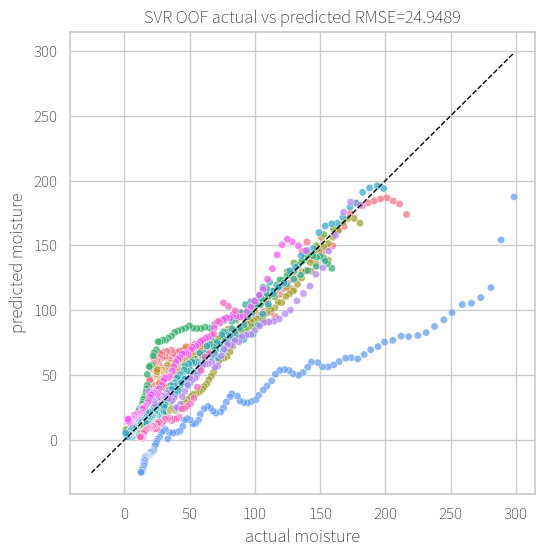

saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\svr_core_features_cnn_woodtype\figures\T12D_drying_curve_overlay_all_species.png


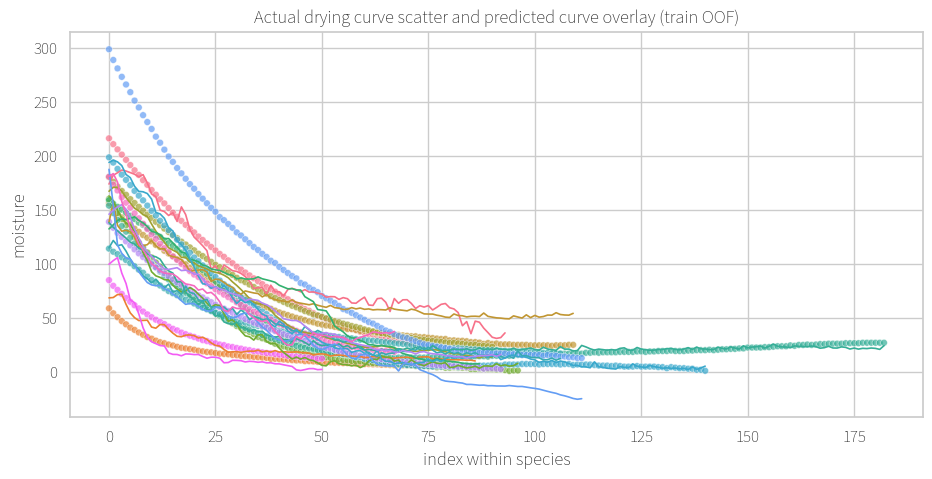

In [5]:
plt.figure(figsize=(6, 6))
sns.scatterplot(data=oof_df, x=TARGET_COL, y="pred_svr", hue=SPECIES_COL, s=28, alpha=0.75, legend=False)
lo = float(np.nanmin([oof_df[TARGET_COL].min(), oof_df["pred_svr"].min()]))
hi = float(np.nanmax([oof_df[TARGET_COL].max(), oof_df["pred_svr"].max()]))
plt.plot([lo, hi], [lo, hi], color="black", lw=1, ls="--")
plt.title(f"SVR OOF actual vs predicted RMSE={summary_df.loc[0, 'oof_rmse']:.4f}")
plt.xlabel("actual moisture")
plt.ylabel("predicted moisture")
savefig("T12D_svr_actual_vs_pred.png")
plt.show()
plt.close("all")

plot_df = oof_df.sort_values([SPECIES_COL, ID_COL]).copy()
plot_df["species_index"] = plot_df.groupby(SPECIES_COL, dropna=False).cumcount()

plt.figure(figsize=(11, 5))
sns.scatterplot(data=plot_df, x="species_index", y=TARGET_COL, hue=SPECIES_COL, s=24, alpha=0.7, legend=False)
sns.lineplot(data=plot_df, x="species_index", y="pred_svr", hue=SPECIES_COL, lw=1.2, legend=False)
plt.title("Actual drying curve scatter and predicted curve overlay (train OOF)")
plt.xlabel("index within species")
plt.ylabel("moisture")
savefig("T12D_drying_curve_overlay_all_species.png")
plt.show()
plt.close("all")

saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\svr_core_features_cnn_woodtype\figures\T12D_drying_curve_by_species_grid.png


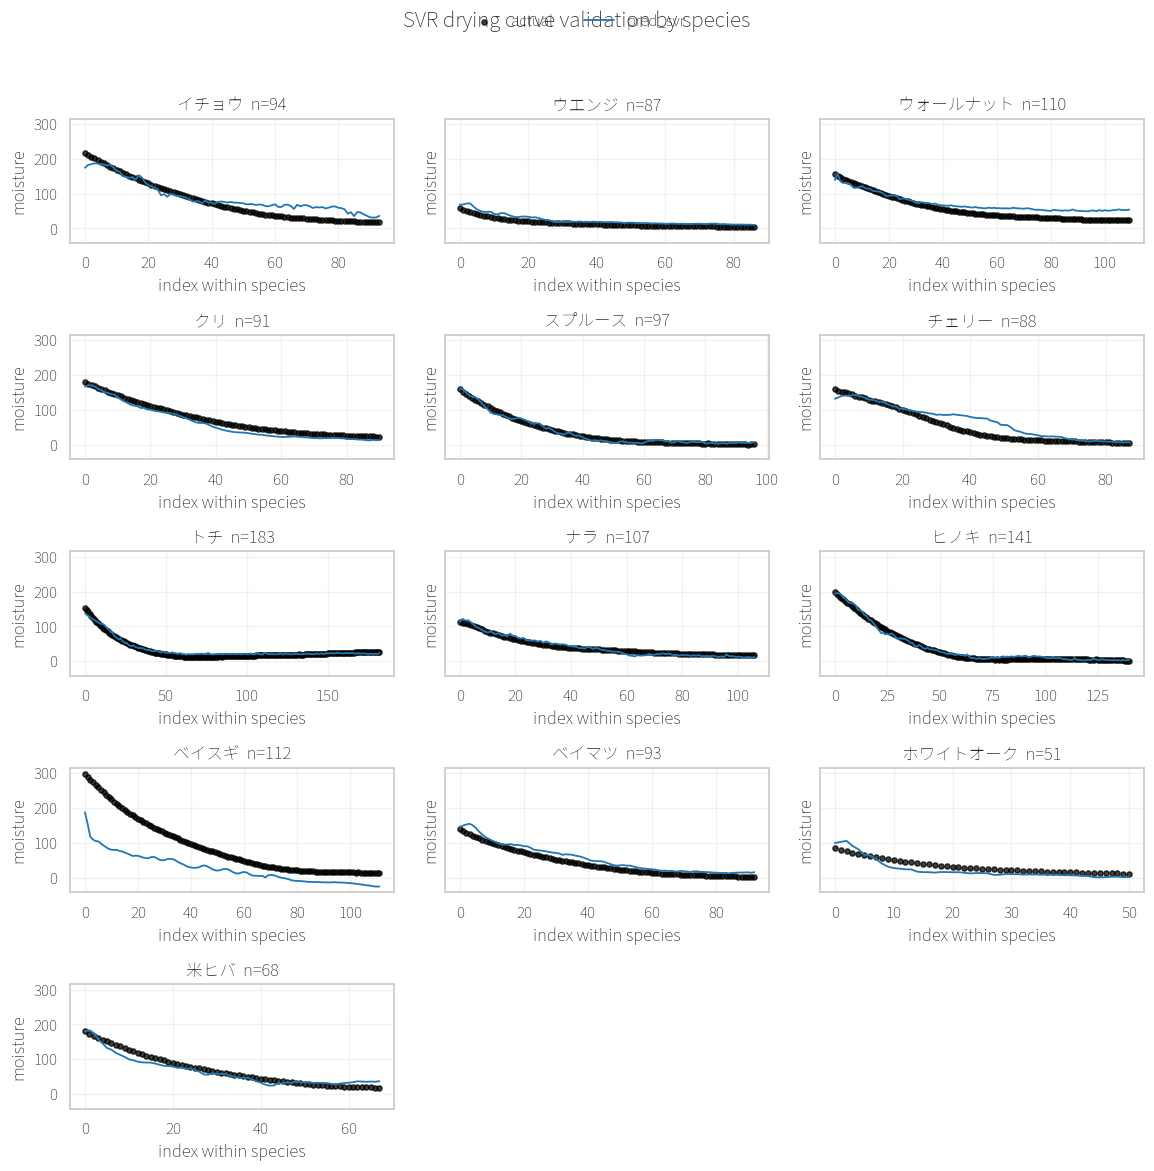

In [6]:
species_values = plot_df[SPECIES_COL].dropna().astype(str).unique().tolist()
ncols = 3 if len(species_values) > 6 else 2
nrows = math.ceil(len(species_values) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.9 * ncols, 2.35 * nrows), sharey=True)
axes = np.asarray(axes).reshape(-1)
for ax, species in zip(axes, species_values):
    g = plot_df[plot_df[SPECIES_COL].astype(str) == species]
    ax.scatter(g["species_index"], g[TARGET_COL], s=14, alpha=0.75, label="actual", color="black")
    ax.plot(g["species_index"], g["pred_svr"], lw=1.3, label="pred_svr", color="tab:blue")
    ax.set_title(f"{species}  n={len(g)}")
    ax.set_xlabel("index within species")
    ax.set_ylabel("moisture")
    ax.grid(True, alpha=0.25)
for ax in axes[len(species_values):]:
    ax.axis("off")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
fig.suptitle("SVR drying curve validation by species", y=0.995, fontsize=15)
fig.tight_layout(rect=(0, 0, 1, 0.97))
savefig("T12D_drying_curve_by_species_grid.png")
plt.show()
plt.close("all")

## Stepwise Feature Search And Robustness Evaluation

In [7]:
def make_svr_pipeline() -> Pipeline:
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf", C=10.0, epsilon=0.1, gamma="scale")),
    ])


def evaluate_feature_set(train_feat: pd.DataFrame, feature_cols: list[str], label: str) -> tuple[dict, pd.DataFrame, pd.DataFrame]:
    work = train_feat[[ID_COL, GROUP_COL, SPECIES_COL, TARGET_COL, *feature_cols]].replace([np.inf, -np.inf], np.nan).copy()
    work = work.loc[work[TARGET_COL].notna()].reset_index(drop=True)
    X = work[feature_cols]
    y = work[TARGET_COL].to_numpy(dtype=float)
    groups = work[SPECIES_COL]
    n_splits = min(5, groups.nunique())
    cv = GroupKFold(n_splits=n_splits)

    oof = np.full(len(work), np.nan, dtype=float)
    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y, groups)):
        model = make_svr_pipeline()
        model.fit(X.iloc[tr_idx], y[tr_idx])
        oof[va_idx] = model.predict(X.iloc[va_idx])

    pred_df = work[[ID_COL, GROUP_COL, SPECIES_COL, TARGET_COL]].copy()
    pred_df["pred_svr"] = oof
    species_df = (
        pred_df.groupby(SPECIES_COL)
        .apply(lambda g: pd.Series({"n": len(g), "rmse": rmse(g[TARGET_COL], g["pred_svr"])}), include_groups=False)
        .reset_index()
    )
    species_values = species_df["rmse"].to_numpy(dtype=float)
    metrics = {
        "label": label,
        "features": "+".join(feature_cols),
        "n_features": len(feature_cols),
        "oof_rmse": rmse(y, oof),
        "species_mean_rmse": float(np.mean(species_values)),
        "species_std_rmse": float(np.std(species_values, ddof=0)),
        "species_min_rmse": float(np.min(species_values)),
        "species_max_rmse": float(np.max(species_values)),
        "species_range_rmse": float(np.max(species_values) - np.min(species_values)),
    }
    metrics["robust_score"] = metrics["species_mean_rmse"] + metrics["species_std_rmse"] + 0.25 * metrics["species_range_rmse"]
    return metrics, species_df, pred_df


def run_forward_stepwise(train_feat: pd.DataFrame, candidate_features: list[str], objective: str = "robust_score"):
    cache: dict[tuple[str, ...], tuple[dict, pd.DataFrame, pd.DataFrame]] = {}

    def cached_eval(features: list[str], label: str):
        key = tuple(features)
        if key not in cache:
            cache[key] = evaluate_feature_set(train_feat, features, label)
        metrics, species_df, pred_df = cache[key]
        metrics = dict(metrics)
        metrics["label"] = label
        return metrics, species_df, pred_df

    selected: list[str] = []
    remaining = list(candidate_features)
    step_rows = []
    best_by_step = []

    while remaining:
        candidates = []
        for feat in remaining:
            trial_features = selected + [feat]
            metrics, species_df, pred_df = cached_eval(trial_features, f"step{len(selected) + 1}__add_{feat}")
            metrics["step"] = len(selected) + 1
            metrics["added_feature"] = feat
            metrics["selected_features"] = "+".join(trial_features)
            candidates.append(metrics)
            step_rows.append(metrics)
        step_df = pd.DataFrame(candidates).sort_values([objective, "oof_rmse", "species_mean_rmse"]).reset_index(drop=True)
        best = step_df.iloc[0].to_dict()
        selected.append(best["added_feature"])
        remaining.remove(best["added_feature"])
        best_by_step.append(best)

    all_trials = pd.DataFrame(step_rows).sort_values([objective, "oof_rmse"]).reset_index(drop=True)
    trace = pd.DataFrame(best_by_step).reset_index(drop=True)
    return all_trials, trace, cache


stepwise_trials, stepwise_trace, stepwise_cache = run_forward_stepwise(train_feat, MODEL_FEATURES, objective="robust_score")

baseline_metrics, baseline_species_rmse, baseline_stepwise_oof = evaluate_feature_set(train_feat, MODEL_FEATURES, "baseline_all_features")
baseline_row = pd.DataFrame([baseline_metrics])
stepwise_summary = pd.concat([baseline_row, stepwise_trials], ignore_index=True, sort=False)
stepwise_summary = stepwise_summary.sort_values(["robust_score", "oof_rmse", "species_mean_rmse"]).reset_index(drop=True)

best_robust_row = stepwise_summary.iloc[0]
best_robust_features = best_robust_row["features"].split("+")
best_robust_metrics, best_robust_species_rmse, best_robust_oof = evaluate_feature_set(train_feat, best_robust_features, "best_robust")

stepwise_trials.to_csv(RESULT_DIR / "T12D_stepwise_all_trials.csv", index=False, encoding="utf-8-sig")
stepwise_trace.to_csv(RESULT_DIR / "T12D_stepwise_forward_trace.csv", index=False, encoding="utf-8-sig")
stepwise_summary.to_csv(RESULT_DIR / "T12D_stepwise_robustness_summary.csv", index=False, encoding="utf-8-sig")
best_robust_species_rmse.to_csv(RESULT_DIR / "T12D_stepwise_best_robust_species_rmse.csv", index=False, encoding="utf-8-sig")
best_robust_oof.to_csv(RESULT_DIR / "T12D_stepwise_best_robust_oof_predictions.csv", index=False, encoding="utf-8-sig")

display(stepwise_trace[["step", "added_feature", "n_features", "oof_rmse", "species_mean_rmse", "species_std_rmse", "species_range_rmse", "robust_score"]])
display(stepwise_summary[["label", "n_features", "oof_rmse", "species_mean_rmse", "species_std_rmse", "species_range_rmse", "species_max_rmse", "robust_score", "features"]].head(15))
display(best_robust_species_rmse.sort_values("rmse", ascending=False))

,step,added_feature,n_features,oof_rmse,species_mean_rmse,species_std_rmse,species_range_rmse,robust_score
0,1,sg1_2100,1,26.394073,20.672692,15.426059,60.898282,51.323321
1,2,softwood_prob,2,23.311155,20.251854,10.652129,44.828249,42.111045
2,3,entropy_woodtype,3,22.791837,19.464125,11.366166,45.025754,42.086729
3,4,pointDiff_1200_2200,4,22.700717,18.367051,12.723999,53.065175,44.357344
4,5,uncertainty_woodtype,5,23.616475,19.117294,13.049539,54.591699,45.814757
5,6,d_1200_2100,6,25.343940,20.044426,14.868900,61.717869,50.342794
6,7,B1900_1970,7,26.531632,21.014832,15.729862,63.837989,52.704191
7,8,meanDiff_1400_1500__1900_2000,8,28.015513,21.938343,16.871180,66.156763,55.348714


,label,n_features,oof_rmse,species_mean_rmse,species_std_rmse,species_range_rmse,species_max_rmse,robust_score,features
0,step3__add_entropy_woodtype,3,22.791837,19.464125,11.366166,45.025754,56.854437,42.086729,sg1_2100+softwood_prob+entropy_woodtype
1,step2__add_softwood_prob,2,23.311155,20.251854,10.652129,44.828249,53.107160,42.111045,sg1_2100+softwood_prob
2,step3__add_uncertainty_woodtype,3,22.753787,19.261644,11.615539,46.728166,57.235698,42.559224,sg1_2100+softwood_prob+uncertainty_woodtype
3,step3__add_pointDiff_1200_2200,3,21.963801,17.208663,12.909593,51.036891,59.170220,42.877479,sg1_2100+softwood_prob+pointDiff_1200_2200
4,step4__add_pointDiff_1200_2200,4,22.700717,18.367051,12.723999,53.065175,58.271095,44.357344,sg1_2100+softwood_prob+entropy_woodtype+pointD...
5,step4__add_uncertainty_woodtype,4,23.901681,20.057686,12.471077,49.482137,60.056465,44.899297,sg1_2100+softwood_prob+entropy_woodtype+uncert...
6,step5__add_uncertainty_woodtype,5,23.616475,19.117294,13.049539,54.591699,60.509061,45.814757,sg1_2100+softwood_prob+entropy_woodtype+pointD...
7,step2__add_pointDiff_1200_2200,2,24.226772,19.023247,14.350662,56.134390,63.903311,47.407506,sg1_2100+pointDiff_1200_2200
8,step3__add_B1900_1970,3,25.119238,20.430691,13.889525,55.726854,64.425528,48.251929,sg1_2100+softwood_prob+B1900_1970
9,step3__add_d_1200_2100,3,24.353374,18.019060,15.515084,62.077673,68.468132,49.053562,sg1_2100+softwood_prob+d_1200_2100


,樹種,n,rmse
9,ベイスギ,112.0,56.854437
0,イチョウ,94.0,24.715589
12,米ヒバ,68.0,21.884807
11,ホワイトオーク,51.0,17.288741
2,ウォールナット,110.0,17.268473
3,クリ,91.0,17.002564
8,ヒノキ,141.0,16.755392
5,チェリー,88.0,16.688269
4,スプルース,97.0,14.018456
6,トチ,183.0,13.459970


saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\svr_core_features_cnn_woodtype\figures\T12D_stepwise_metric_trace.png


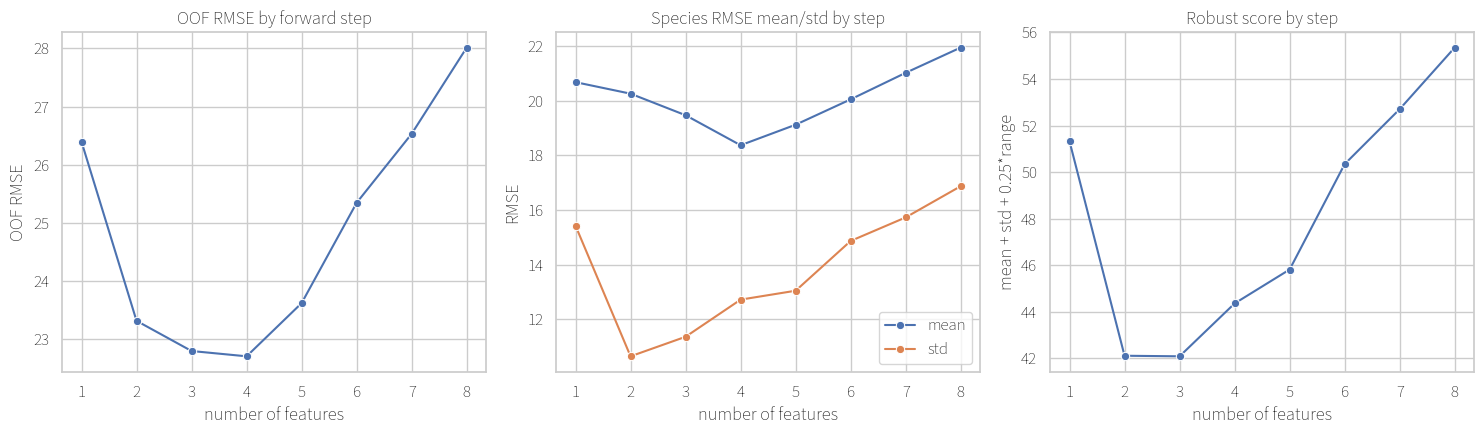

saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\svr_core_features_cnn_woodtype\figures\T12D_stepwise_species_mean_vs_std.png


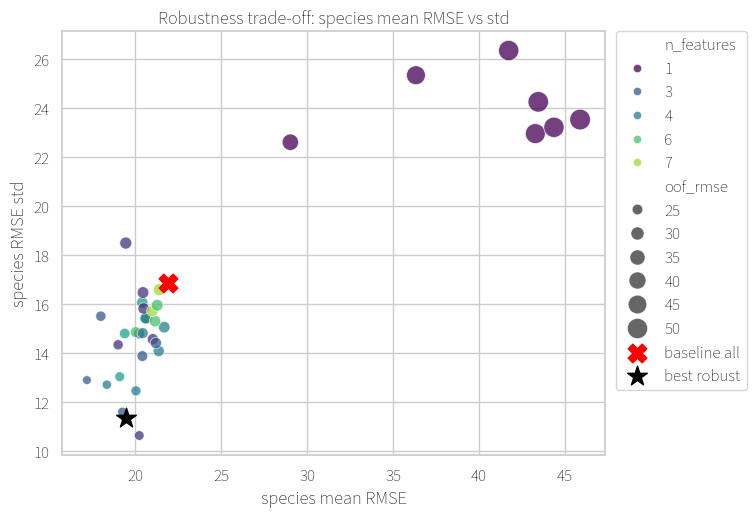

saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\svr_core_features_cnn_woodtype\figures\T12D_stepwise_top_robust_models.png


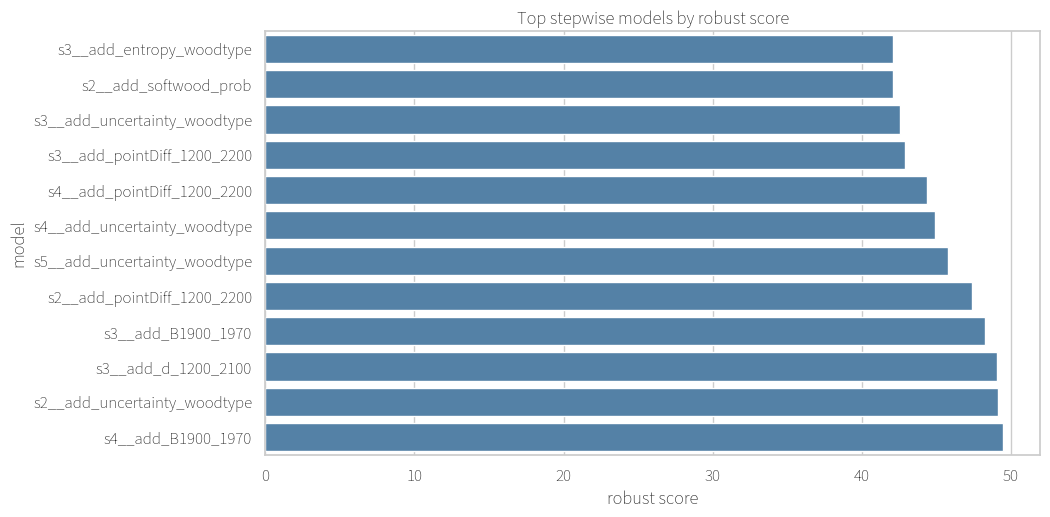

In [8]:
plot_stepwise = stepwise_trace.copy()
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.lineplot(data=plot_stepwise, x="n_features", y="oof_rmse", marker="o", ax=axes[0])
axes[0].set_title("OOF RMSE by forward step")
axes[0].set_xlabel("number of features")
axes[0].set_ylabel("OOF RMSE")

sns.lineplot(data=plot_stepwise, x="n_features", y="species_mean_rmse", marker="o", label="mean", ax=axes[1])
sns.lineplot(data=plot_stepwise, x="n_features", y="species_std_rmse", marker="o", label="std", ax=axes[1])
axes[1].set_title("Species RMSE mean/std by step")
axes[1].set_xlabel("number of features")
axes[1].set_ylabel("RMSE")

sns.lineplot(data=plot_stepwise, x="n_features", y="robust_score", marker="o", ax=axes[2])
axes[2].set_title("Robust score by step")
axes[2].set_xlabel("number of features")
axes[2].set_ylabel("mean + std + 0.25*range")
fig.tight_layout()
savefig("T12D_stepwise_metric_trace.png")
plt.show()
plt.close("all")

plt.figure(figsize=(7, 5.5))
sns.scatterplot(
    data=stepwise_summary,
    x="species_mean_rmse",
    y="species_std_rmse",
    size="oof_rmse",
    hue="n_features",
    palette="viridis",
    sizes=(40, 220),
    alpha=0.75,
)
plt.scatter([baseline_metrics["species_mean_rmse"]], [baseline_metrics["species_std_rmse"]], marker="X", s=180, color="red", label="baseline all")
plt.scatter([best_robust_metrics["species_mean_rmse"]], [best_robust_metrics["species_std_rmse"]], marker="*", s=220, color="black", label="best robust")
plt.title("Robustness trade-off: species mean RMSE vs std")
plt.xlabel("species mean RMSE")
plt.ylabel("species RMSE std")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
savefig("T12D_stepwise_species_mean_vs_std.png")
plt.show()
plt.close("all")

top_models = stepwise_summary.head(12).copy()
top_models["short_label"] = top_models["label"].astype(str).str.replace("step", "s", regex=False).str[:35]
plt.figure(figsize=(10, 5.5))
sns.barplot(data=top_models, y="short_label", x="robust_score", color="steelblue")
plt.title("Top stepwise models by robust score")
plt.xlabel("robust score")
plt.ylabel("model")
savefig("T12D_stepwise_top_robust_models.png")
plt.show()
plt.close("all")

saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\svr_core_features_cnn_woodtype\figures\T12D_stepwise_species_rmse_heatmap.png


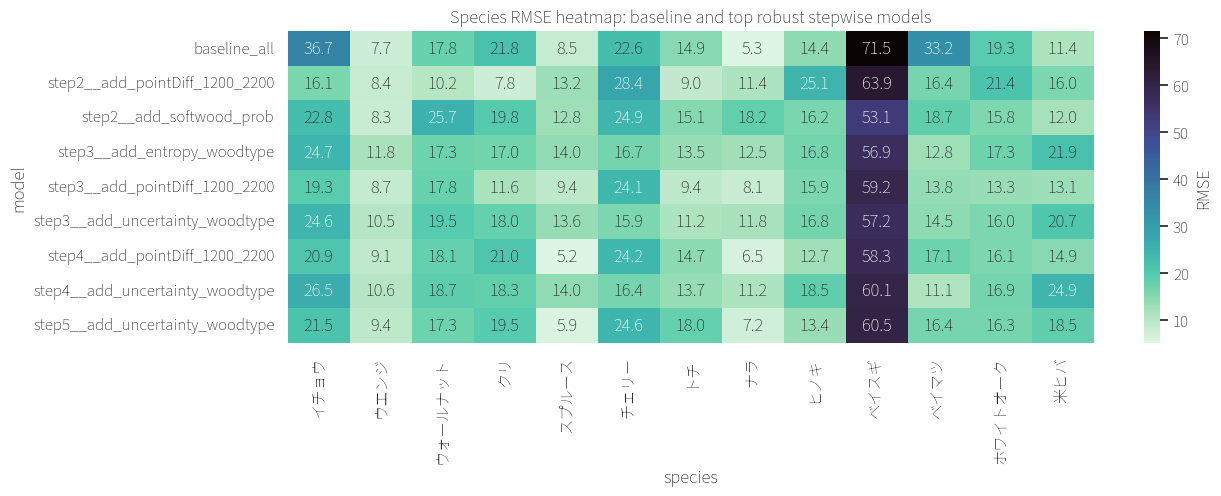

In [9]:
# Species RMSE heatmap for baseline and top robust stepwise models
heat_rows = []
model_specs = [("baseline_all", MODEL_FEATURES)]
for _, row in stepwise_summary.head(8).iterrows():
    model_specs.append((str(row["label"]), str(row["features"]).split("+")))

seen_labels = set()
for label, feats in model_specs:
    if label in seen_labels:
        continue
    seen_labels.add(label)
    _, sp_df, _ = evaluate_feature_set(train_feat, feats, label)
    tmp = sp_df[[SPECIES_COL, "rmse"]].copy()
    tmp["model"] = label
    heat_rows.append(tmp)

species_heat_df = pd.concat(heat_rows, ignore_index=True)
species_heat_df.to_csv(RESULT_DIR / "T12D_stepwise_species_rmse_heatmap_table.csv", index=False, encoding="utf-8-sig")
heat = species_heat_df.pivot(index="model", columns=SPECIES_COL, values="rmse")
plt.figure(figsize=(13, max(4, 0.45 * len(heat))))
sns.heatmap(heat, annot=True, fmt=".1f", cmap="mako_r", cbar_kws={"label": "RMSE"})
plt.title("Species RMSE heatmap: baseline and top robust stepwise models")
plt.xlabel("species")
plt.ylabel("model")
savefig("T12D_stepwise_species_rmse_heatmap.png")
plt.show()
plt.close("all")

saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\svr_core_features_cnn_woodtype\figures\T12D_stepwise_drying_curve_baseline_vs_best_robust.png


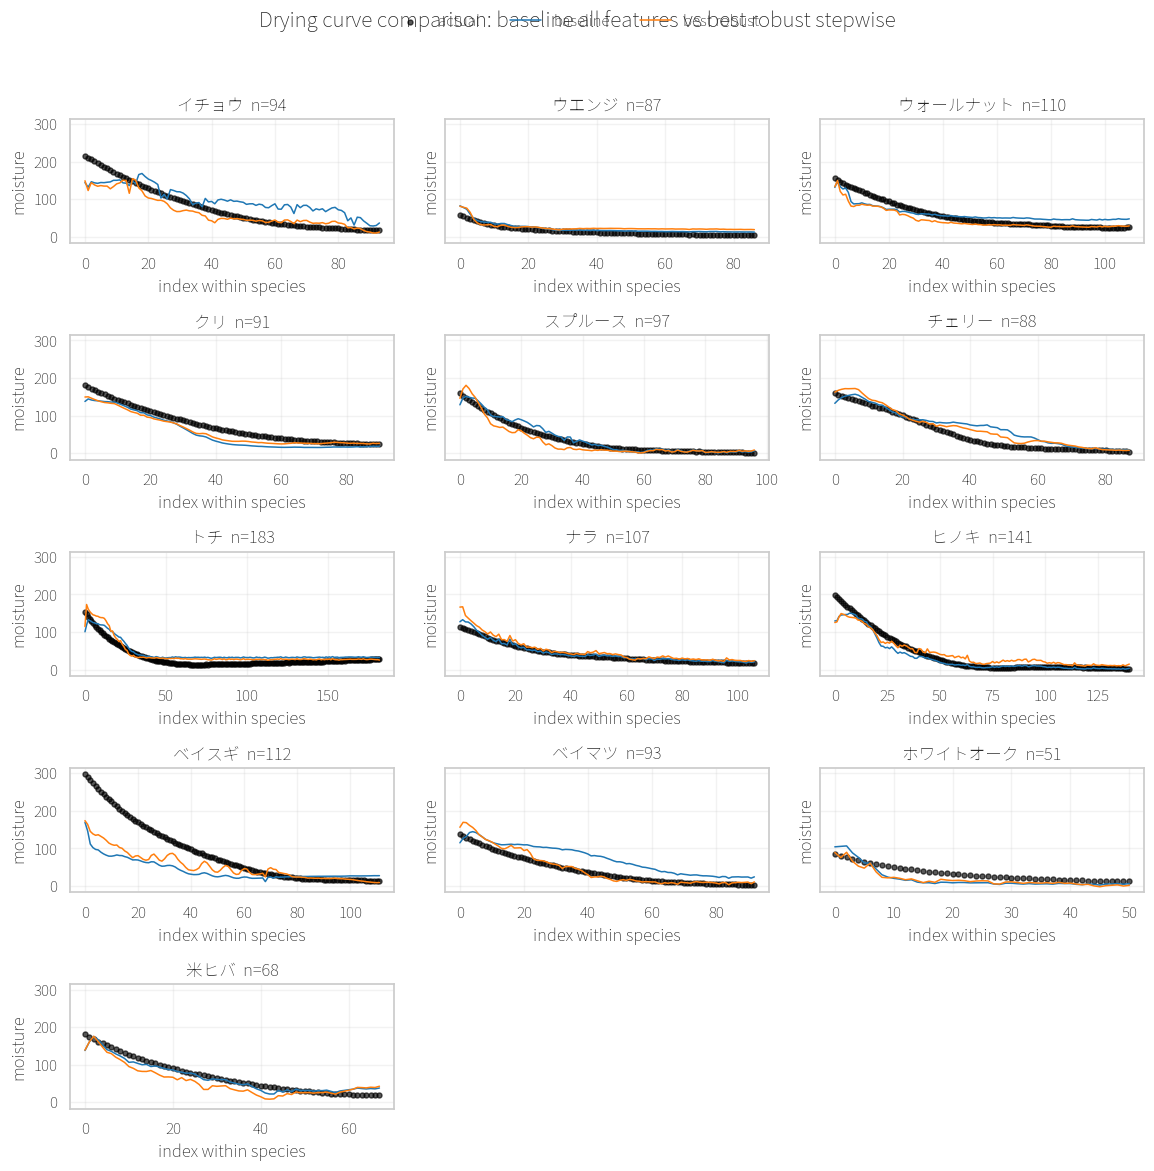

Best robust stepwise model
features: ['sg1_2100', 'softwood_prob', 'entropy_woodtype']
OOF RMSE=22.7918
species mean RMSE=19.4641
species std RMSE=11.3662
species range RMSE=45.0258


In [10]:
# Drying curve comparison for baseline-all vs best robust stepwise model
compare_df = baseline_stepwise_oof[[ID_COL, SPECIES_COL, TARGET_COL, "pred_svr"]].rename(columns={"pred_svr": "pred_baseline_all"})
compare_df = compare_df.merge(
    best_robust_oof[[ID_COL, "pred_svr"]].rename(columns={"pred_svr": "pred_best_robust"}),
    on=ID_COL,
    how="left",
)
compare_df = compare_df.sort_values([SPECIES_COL, ID_COL]).copy()
compare_df["species_index"] = compare_df.groupby(SPECIES_COL, dropna=False).cumcount()

species_values = compare_df[SPECIES_COL].dropna().astype(str).unique().tolist()
ncols = 3 if len(species_values) > 6 else 2
nrows = math.ceil(len(species_values) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.9 * ncols, 2.35 * nrows), sharey=True)
axes = np.asarray(axes).reshape(-1)
for ax, species in zip(axes, species_values):
    g = compare_df[compare_df[SPECIES_COL].astype(str) == species]
    ax.scatter(g["species_index"], g[TARGET_COL], s=13, alpha=0.65, color="black", label="actual")
    ax.plot(g["species_index"], g["pred_baseline_all"], lw=1.1, color="tab:blue", label="baseline")
    ax.plot(g["species_index"], g["pred_best_robust"], lw=1.1, color="tab:orange", label="best robust")
    ax.set_title(f"{species}  n={len(g)}")
    ax.set_xlabel("index within species")
    ax.set_ylabel("moisture")
    ax.grid(True, alpha=0.25)
for ax in axes[len(species_values):]:
    ax.axis("off")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)
fig.suptitle("Drying curve comparison: baseline all features vs best robust stepwise", y=0.995, fontsize=15)
fig.tight_layout(rect=(0, 0, 1, 0.97))
savefig("T12D_stepwise_drying_curve_baseline_vs_best_robust.png")
plt.show()
plt.close("all")

print("Best robust stepwise model")
print("features:", best_robust_features)
print(f"OOF RMSE={best_robust_metrics['oof_rmse']:.4f}")
print(f"species mean RMSE={best_robust_metrics['species_mean_rmse']:.4f}")
print(f"species std RMSE={best_robust_metrics['species_std_rmse']:.4f}")
print(f"species range RMSE={best_robust_metrics['species_range_rmse']:.4f}")

## Final Robust Model: Train All, Test Predict, Submission

In [14]:
ROBUST_MODEL_FEATURES = ["sg1_2100", "softwood_prob", "entropy_woodtype"]

robust_model = make_svr_pipeline()
X_train_robust = train_feat[ROBUST_MODEL_FEATURES].replace([np.inf, -np.inf], np.nan)
y_train_robust = train_feat[TARGET_COL].to_numpy(dtype=float)
X_test_robust = test_feat[ROBUST_MODEL_FEATURES].replace([np.inf, -np.inf], np.nan)

robust_model.fit(X_train_robust, y_train_robust)
test_pred_robust = robust_model.predict(X_test_robust)

submission = pd.DataFrame({ID_COL: test_feat[ID_COL].values, "pred": test_pred_robust})
submission_path = RESULT_DIR / "submission_robust_svr_sg1_softwood_entropy.csv"
submission_latest_path = RESULT_DIR / "submission.csv"
submission.to_csv(submission_path, index=False, encoding="utf-8-sig", header=False)
submission.to_csv(submission_latest_path, index=False, encoding="utf-8-sig", header=False)

test_curve_df = test_feat[[ID_COL, GROUP_COL, SPECIES_COL, *ROBUST_MODEL_FEATURES]].copy()
test_curve_df["pred"] = test_pred_robust
test_curve_df = test_curve_df.sort_values([SPECIES_COL, ID_COL]).reset_index(drop=True)
test_curve_df["species_index"] = test_curve_df.groupby(SPECIES_COL, dropna=False).cumcount()
test_curve_df.to_csv(RESULT_DIR / "T12D_robust_model_test_prediction_curve.csv", index=False, encoding="utf-8-sig")

display(submission.head())
print("saved:", submission_path)
print("saved:", submission_latest_path)
print("features:", ROBUST_MODEL_FEATURES)
print("test pred summary")
display(test_curve_df.groupby(SPECIES_COL)["pred"].agg(["count", "mean", "std", "min", "max"]).reset_index())

,sample number,pred
0,95,163.051402
1,96,144.094388
2,97,133.917181
3,98,133.449408
4,99,134.662985


saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\svr_core_features_cnn_woodtype\submission_robust_svr_sg1_softwood_entropy.csv
saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\svr_core_features_cnn_woodtype\submission.csv
features: ['sg1_2100', 'softwood_prob', 'entropy_woodtype']
test pred summary


,樹種,count,mean,std,min,max
0,クスノキ,96,47.915693,34.790681,23.943128,163.051402
1,ケヤキ,63,44.250659,28.094850,17.882772,127.834077
2,スギ,192,29.961311,34.932914,7.014373,155.435491
3,タモ,45,46.835262,33.889476,21.270366,148.417334
4,チーク,101,32.344534,31.219411,8.658860,127.684124
5,ヤマザクラ,53,47.659645,37.118786,20.477403,151.113435


saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\svr_core_features_cnn_woodtype\figures\T12D_robust_test_prediction_curve_overlay.png


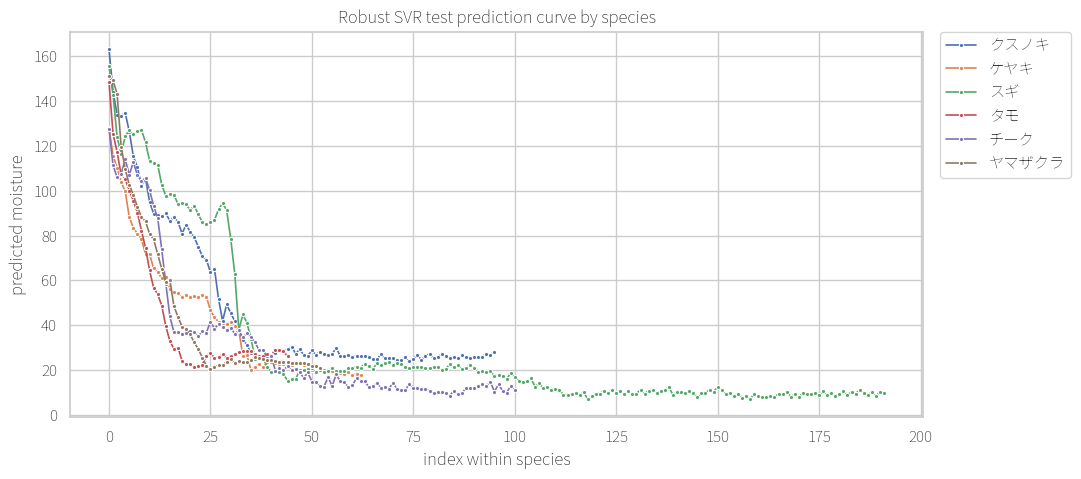

saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\svr_core_features_cnn_woodtype\figures\T12D_robust_test_prediction_curve_by_species_grid.png


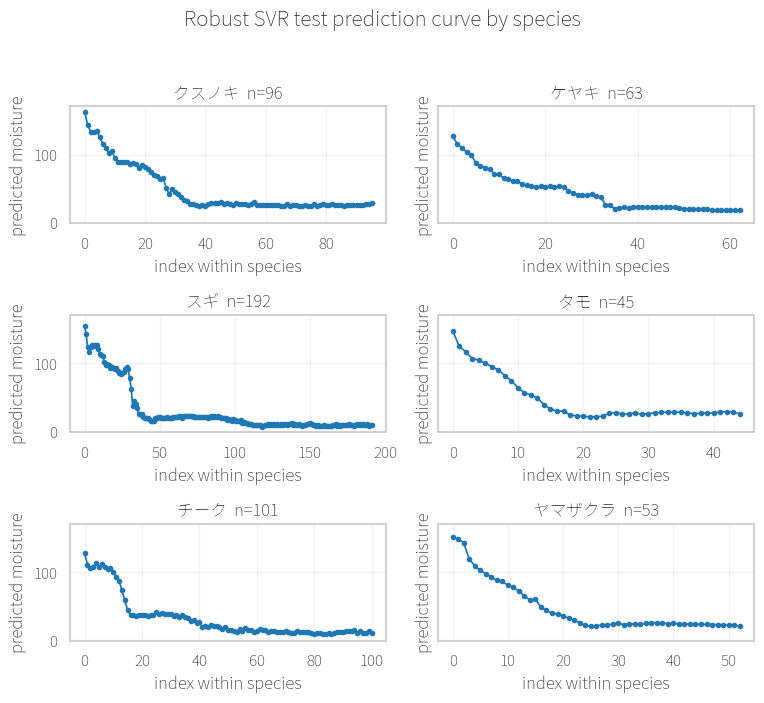

In [12]:
plt.figure(figsize=(11, 5))
sns.lineplot(data=test_curve_df, x="species_index", y="pred", hue=SPECIES_COL, marker="o", ms=3, lw=1.2)
plt.title("Robust SVR test prediction curve by species")
plt.xlabel("index within species")
plt.ylabel("predicted moisture")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
savefig("T12D_robust_test_prediction_curve_overlay.png")
plt.show()
plt.close("all")

species_values = test_curve_df[SPECIES_COL].dropna().astype(str).unique().tolist()
ncols = 3 if len(species_values) > 6 else 2
nrows = math.ceil(len(species_values) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.9 * ncols, 2.35 * nrows), sharey=True)
axes = np.asarray(axes).reshape(-1)
for ax, species in zip(axes, species_values):
    g = test_curve_df[test_curve_df[SPECIES_COL].astype(str) == species]
    ax.plot(g["species_index"], g["pred"], marker="o", ms=3, lw=1.25, color="tab:blue")
    ax.set_title(f"{species}  n={len(g)}")
    ax.set_xlabel("index within species")
    ax.set_ylabel("predicted moisture")
    ax.grid(True, alpha=0.25)
for ax in axes[len(species_values):]:
    ax.axis("off")
fig.suptitle("Robust SVR test prediction curve by species", y=0.995, fontsize=15)
fig.tight_layout(rect=(0, 0, 1, 0.97))
savefig("T12D_robust_test_prediction_curve_by_species_grid.png")
plt.show()
plt.close("all")

## Summary

In [13]:
print("SVR 実験まとめ")
print(f"- 使用特徴量: {MODEL_FEATURES}")
print(f"- GroupKFold OOF RMSE: {summary_df.loc[0, 'oof_rmse']:.4f}")
print(f"- 最もRMSEが大きい樹種: {species_rmse_df.iloc[0][SPECIES_COL]} RMSE={species_rmse_df.iloc[0]['rmse']:.4f}")
print(f"- 図とCSV保存先: {RESULT_DIR}")
if "best_robust_metrics" in globals():
    print("Stepwise robust model:")
    print(f"- features: {best_robust_features}")
    print(f"- OOF RMSE: {best_robust_metrics['oof_rmse']:.4f}")
    print(f"- species mean RMSE: {best_robust_metrics['species_mean_rmse']:.4f}")
    print(f"- species std RMSE: {best_robust_metrics['species_std_rmse']:.4f}")
    print(f"- species range RMSE: {best_robust_metrics['species_range_rmse']:.4f}")


SVR 実験まとめ
- 使用特徴量: ['d_1200_2100', 'meanDiff_1400_1500__1900_2000', 'B1900_1970', 'sg1_2100', 'pointDiff_1200_2200', 'softwood_prob', 'entropy_woodtype', 'uncertainty_woodtype']
- GroupKFold OOF RMSE: 24.9489
- 最もRMSEが大きい樹種: ベイスギ RMSE=74.1798
- 図とCSV保存先: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\svr_core_features_cnn_woodtype
Stepwise robust model:
- features: ['sg1_2100', 'softwood_prob', 'entropy_woodtype']
- OOF RMSE: 22.7918
- species mean RMSE: 19.4641
- species std RMSE: 11.3662
- species range RMSE: 45.0258
